# Visual Speech Recognition — Training (BPE tokenizer)

Версия `train.ipynb` для датасета с уменьшенным словарём (BPE, ≤1200 токенов).
Датасет пересобран ноутбуком `rebuild_dataset.ipynb`.

**Улучшения по сравнению с оригиналом:**
- Early stopping (patience=25)
- Аугментация кадров при обучении (яркость, контраст, шум)
- dropout 0.4 → 0.5
- LR 3e-4 → 1.5e-4, weight_decay 1e-5 → 1e-3

In [11]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
import pickle
import numpy as np
import copy
from collections import Counter
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from datetime import datetime

from torch.optim.lr_scheduler import LinearLR, SequentialLR, CosineAnnealingLR
from tokenizers import Tokenizer

from model_2d import LipReadingTransformer2D

## Гиперпараметры и конфигурация

In [ ]:
from model_2d import load_config

# ── Пути и сплиты ──
DATA_PATH         = "D:/Datasets/Dataset_720_proc_bpe"
MODEL_CONFIG_PATH = "configs/model_config_v6.json"
TOKENIZER_PATH    = "configs/bpe_tokenizer/tokenizer.json"

TRAIN_CLIPS = [f"pt{i}" for i in range(1, 12)]   # pt1 – pt11
VAL_CLIPS   = [f"pt{i}" for i in range(12, 14)]   # pt12 – pt13
TEST_CLIPS  = [f"pt{i}" for i in range(14, 16)]   # pt14 – pt15

# ── Загрузка конфига модели ──
MODEL_CONFIG = load_config(MODEL_CONFIG_PATH)

VOCAB_SIZE = MODEL_CONFIG["vocab_size"]
MAX_FRAMES = MODEL_CONFIG["max_frames"]
MAX_TOKENS = MODEL_CONFIG["max_tokens"]

# ── Скользящее окно ──
FRAME_STRIDE      = 10
TOKEN_CONTENT_LEN = MAX_TOKENS - 1
TOKEN_STRIDE      = 3

# ── Специальные токены из BPE-токенизатора ──
bpe_tokenizer = Tokenizer.from_file(TOKENIZER_PATH)
PAD_TOKEN_ID  = bpe_tokenizer.token_to_id("<|pad|>")
BOS_TOKEN_ID  = bpe_tokenizer.token_to_id("<|bos|>")
EOS_TOKEN_ID  = bpe_tokenizer.token_to_id("<|eos|>")

# ── Обучение ──
BATCH_SIZE    = 12
NUM_EPOCHS    = 300
WARMUP_EPOCHS = 50
LEARNING_RATE = 1.5e-4
WEIGHT_DECAY  = 1e-3
PATIENCE      = 100

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
print(f"Config: d_model={MODEL_CONFIG['d_model']}, nhead={MODEL_CONFIG['nhead']}, "
      f"num_layers={MODEL_CONFIG['num_layers']}, dropout={MODEL_CONFIG['dropout']}")
print(f"vocab_size: {VOCAB_SIZE}")
print(f"Спец-токены: PAD={PAD_TOKEN_ID}, BOS={BOS_TOKEN_ID}, EOS={EOS_TOKEN_ID}")
print(f"LR={LEARNING_RATE}, weight_decay={WEIGHT_DECAY}, patience={PATIENCE}")

Device: cuda
Config: d_model=64, nhead=4, num_layers=2, dropout=0.5
vocab_size: 1200
Спец-токены: PAD=0, BOS=1, EOS=2
LR=0.00015, weight_decay=0.001, patience=75


## Dataset со скользящим окном и аугментацией

In [13]:
class LipReadingDataset(Dataset):
    """
    Загружает .pkl-файлы из указанных клипов.
    Если кадров > MAX_FRAMES, нарезает скользящим окном:
        кадры:  окно 40, сдвиг 10
        токены: окно 11, сдвиг 3

    augment=True включает случайные искажения кадров (только для train):
        - яркость ×[0.7, 1.3]
        - контраст (сдвиг вокруг 0.5) ×[0.8, 1.2]
        - гауссов шум σ=0.02
    Горизонтальный флип НЕ применяется: губы асимметричны при чтении.
    """

    def __init__(self, data_path, clip_names,
                 max_frames=MAX_FRAMES, frame_stride=FRAME_STRIDE,
                 max_tokens=MAX_TOKENS, token_stride=TOKEN_STRIDE,
                 augment=False):
        self.max_frames = max_frames
        self.max_tokens = max_tokens
        self.token_content_len = max_tokens - 1
        self.augment = augment

        data_path = Path(data_path)
        self.samples = []  # (pkl_path, frame_start, token_start, actual_frames)

        for clip_name in sorted(clip_names):
            clip_dir = data_path / clip_name
            if not clip_dir.exists():
                print(f"[!] Папка {clip_dir} не найдена, пропуск")
                continue

            pkl_files = sorted(
                clip_dir.glob("*.pkl"),
                key=lambda f: int(f.stem.split("_")[-1])
            )

            for pkl_file in pkl_files:
                with open(pkl_file, "rb") as f:
                    data = pickle.load(f)

                num_frames = data["num_frames"]
                num_tokens = len(data["input_ids"])

                if num_frames <= max_frames:
                    self.samples.append((str(pkl_file), 0, 0, num_frames))
                else:
                    f_start, t_start = 0, 0
                    while f_start + max_frames <= num_frames:
                        t_end = min(t_start + self.token_content_len, num_tokens)
                        if t_end > t_start:
                            self.samples.append((str(pkl_file), f_start, t_start, max_frames))
                        f_start += frame_stride
                        t_start += token_stride

        aug_str = "+ augment" if augment else ""
        print(f"Загружено {len(self.samples)} сэмплов из {len(clip_names)} клипов {aug_str}")

    def _augment_frames(self, chunk):
        """chunk: float32 (T, C, H, W) в [0, 1]"""
        # Случайная яркость
        if np.random.rand() > 0.5:
            factor = np.float32(np.random.uniform(0.7, 1.3))
            chunk = np.clip(chunk * factor, 0.0, 1.0)

        # Случайный контраст (масштаб вокруг 0.5)
        if np.random.rand() > 0.5:
            factor = np.float32(np.random.uniform(0.8, 1.2))
            chunk = np.clip((chunk - 0.5) * factor + 0.5, 0.0, 1.0)

        # Гауссов шум
        if np.random.rand() > 0.5:
            noise = np.random.normal(0, 0.02, chunk.shape).astype(np.float32)
            chunk = np.clip(chunk + noise, 0.0, 1.0)

        return chunk

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        pkl_path, f_start, t_start, actual_frames = self.samples[idx]

        with open(pkl_path, "rb") as f:
            data = pickle.load(f)

        frames = data["frames"]
        ids    = data["input_ids"]

        # ── Кадры ──
        chunk = frames[f_start : f_start + self.max_frames]
        chunk = np.stack(chunk)                                       # (T, H, W, C)
        chunk = np.transpose(chunk, (0, 3, 1, 2)).astype(np.float32) / 255.0  # (T, C, H, W)

        n_real_frames = chunk.shape[0]
        if n_real_frames < self.max_frames:
            pad = np.zeros(
                (self.max_frames - n_real_frames, *chunk.shape[1:]),
                dtype=np.float32,
            )
            chunk = np.concatenate([chunk, pad], axis=0)

        if self.augment:
            chunk = self._augment_frames(chunk)

        src_padding_mask = [False] * n_real_frames + [True] * (self.max_frames - n_real_frames)

        # ── Токены ──
        content = ids[t_start : t_start + self.token_content_len]

        decoder_input = [BOS_TOKEN_ID] + content
        target        = content + [EOS_TOKEN_ID]

        dec_len = len(decoder_input)
        decoder_input += [PAD_TOKEN_ID] * (self.max_tokens - dec_len)
        target        += [PAD_TOKEN_ID] * (self.max_tokens - len(target))

        tgt_padding_mask = [False] * dec_len + [True] * (self.max_tokens - dec_len)

        return {
            "frames":           torch.tensor(chunk, dtype=torch.float32),
            "src_padding_mask": torch.tensor(src_padding_mask, dtype=torch.bool),
            "decoder_input":    torch.tensor(decoder_input, dtype=torch.long),
            "target":           torch.tensor(target, dtype=torch.long),
            "tgt_padding_mask": torch.tensor(tgt_padding_mask, dtype=torch.bool),
        }

## Создание датасетов и загрузчиков

## Взвешенный loss: подсчёт частот токенов

In [ ]:
# Считаем частоты токенов по train-набору.
# Цель: модель не должна схлопываться в предсказание самого частого токена.
# Веса = обратная частота, нормированная на число уникальных токенов.

token_counts = Counter()
seen_files = set()
for pkl_path, _, _, _ in train_dataset.samples:
    if pkl_path in seen_files:
        continue
    seen_files.add(pkl_path)
    with open(pkl_path, "rb") as f:
        data = pickle.load(f)
    token_counts.update(data["input_ids"])

total = sum(token_counts.values())
token_weights = torch.ones(VOCAB_SIZE, dtype=torch.float32)
for token_id, cnt in token_counts.items():
    if token_id < VOCAB_SIZE:
        token_weights[token_id] = total / (len(token_counts) * cnt)
token_weights = token_weights.clamp(max=10.0)

# ── Исправление весов спец-токенов ──
# EOS не входит в input_ids → получал дефолтный вес 1.0, что в ~45× больше
# среднего веса обычных токенов. Это провоцирует модель всегда предсказывать EOS.
avg_weight = token_weights[token_weights < 10.0].mean().item()
token_weights[EOS_TOKEN_ID] = avg_weight   # EOS — не «бесценный»
token_weights[BOS_TOKEN_ID] = 0.0          # BOS никогда не является таргетом
token_weights[PAD_TOKEN_ID] = 0.0          # PAD исключён через ignore_index

print(f"Уникальных токенов в train: {len(token_counts)}")
print(f"Средний вес обычного токена: {avg_weight:.4f}")
print(f"Топ-5 частых:  {token_counts.most_common(5)}")
print(f"Топ-5 редких:  {token_counts.most_common()[:-6:-1]}")
dot_id = bpe_tokenizer.token_to_id(".")
if dot_id is not None:
    print(f"Вес токена '.': {token_weights[dot_id]:.4f}")
print(f"Вес EOS:   {token_weights[EOS_TOKEN_ID]:.4f}")
print(f"Диапазон весов: [{token_weights[token_weights > 0].min():.3f}, {token_weights.max():.3f}]")

In [15]:
# augment=True только для train — val и test всегда без искажений
train_dataset = LipReadingDataset(DATA_PATH, TRAIN_CLIPS, augment=True)
val_dataset   = LipReadingDataset(DATA_PATH, VAL_CLIPS,   augment=False)
test_dataset  = LipReadingDataset(DATA_PATH, TEST_CLIPS,  augment=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

batch = next(iter(train_loader))
print("frames:          ", batch["frames"].shape)
print("src_padding_mask:", batch["src_padding_mask"].shape)
print("decoder_input:   ", batch["decoder_input"].shape)
print("target:          ", batch["target"].shape)
print("tgt_padding_mask:", batch["tgt_padding_mask"].shape)

[!] Папка D:\Datasets\Dataset_720_proc_bpe\pt10 не найдена, пропуск
Загружено 996 сэмплов из 11 клипов + augment
Загружено 334 сэмплов из 2 клипов 
Загружено 316 сэмплов из 2 клипов 
frames:           torch.Size([12, 40, 3, 64, 96])
src_padding_mask: torch.Size([12, 40])
decoder_input:    torch.Size([12, 12])
target:           torch.Size([12, 12])
tgt_padding_mask: torch.Size([12, 12])


## Модель, оптимизатор, функция потерь

In [16]:
model = LipReadingTransformer2D(MODEL_CONFIG).to(DEVICE)

optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

warmup_scheduler = LinearLR(optimizer, start_factor=0.05, total_iters=WARMUP_EPOCHS)
main_scheduler   = CosineAnnealingLR(optimizer, T_max=(NUM_EPOCHS - WARMUP_EPOCHS)//2, eta_min=1e-6)
scheduler        = SequentialLR(optimizer, schedulers=[warmup_scheduler, main_scheduler],
                                milestones=[WARMUP_EPOCHS])

# Взвешенный loss: штрафует за предсказание частых токенов сильнее, чем редких.
# Это устраняет mode collapse ("." на все входы).
criterion = nn.CrossEntropyLoss(
    weight=token_weights.to(DEVICE),
    ignore_index=PAD_TOKEN_ID,
    label_smoothing=0.1,
)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Параметры: {total_params:,} всего, {trainable_params:,} обучаемых")

Параметры: 423,952 всего, 423,952 обучаемых


## Функции обучения и валидации

In [ ]:
def train_one_epoch(model, loader, criterion, optimizer, device, log_grads=False):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_tokens = 0
    grad_log = {"enc_cnn": 0.0, "enc_tr": 0.0, "dec": 0.0, "n": 0}

    for batch in loader:
        frames       = batch["frames"].to(device)
        src_pad_mask = batch["src_padding_mask"].to(device)
        dec_input    = batch["decoder_input"].to(device)
        target       = batch["target"].to(device)
        tgt_pad_mask = batch["tgt_padding_mask"].to(device)

        logits = model(frames, dec_input,
                       tgt_padding_mask=tgt_pad_mask,
                       src_padding_mask=src_pad_mask)

        loss = criterion(logits.reshape(-1, VOCAB_SIZE), target.reshape(-1))

        optimizer.zero_grad()
        loss.backward()

        if log_grads:
            def _gnorm(params):
                return sum(p.grad.norm().item()**2 for p in params if p.grad is not None) ** 0.5
            grad_log["enc_cnn"] += _gnorm(model.encoder.cnn_backbone.parameters())
            grad_log["enc_tr"]  += _gnorm(model.encoder.transformer_encoder.parameters())
            grad_log["dec"]     += _gnorm(model.decoder.parameters())
            grad_log["n"]       += 1

        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item() * frames.size(0)

        preds = logits.argmax(dim=-1)
        mask  = target != PAD_TOKEN_ID
        total_correct += (preds[mask] == target[mask]).sum().item()
        total_tokens  += mask.sum().item()

    avg_loss = total_loss / len(loader.dataset)
    accuracy = total_correct / total_tokens if total_tokens > 0 else 0.0

    if log_grads and grad_log["n"] > 0:
        n = grad_log["n"]
        print(f"  GradNorm | enc_cnn={grad_log['enc_cnn']/n:.4f} "
              f"enc_tr={grad_log['enc_tr']/n:.4f} dec={grad_log['dec']/n:.4f}")

    return avg_loss, accuracy


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_tokens = 0

    for batch in loader:
        frames       = batch["frames"].to(device)
        src_pad_mask = batch["src_padding_mask"].to(device)
        dec_input    = batch["decoder_input"].to(device)
        target       = batch["target"].to(device)
        tgt_pad_mask = batch["tgt_padding_mask"].to(device)

        logits = model(frames, dec_input,
                       tgt_padding_mask=tgt_pad_mask,
                       src_padding_mask=src_pad_mask)

        loss = criterion(logits.reshape(-1, VOCAB_SIZE), target.reshape(-1))
        total_loss += loss.item() * frames.size(0)

        preds = logits.argmax(dim=-1)
        mask  = target != PAD_TOKEN_ID
        total_correct += (preds[mask] == target[mask]).sum().item()
        total_tokens  += mask.sum().item()

    avg_loss = total_loss / len(loader.dataset)
    accuracy = total_correct / total_tokens if total_tokens > 0 else 0.0
    return avg_loss, accuracy

## Цикл обучения с early stopping

### Диагностика: overfit на одном батче

Если модель не может выучить один батч за 300 шагов — есть архитектурная
проблема. Ожидаемый результат: `acc → 0.9+`.

In [ ]:
_model_dbg = LipReadingTransformer2D(MODEL_CONFIG).to(DEVICE)
_opt_dbg   = torch.optim.Adam(_model_dbg.parameters(), lr=1e-3)
_crit_dbg  = nn.CrossEntropyLoss(ignore_index=PAD_TOKEN_ID)

_b      = next(iter(train_loader))
_frames = _b["frames"].to(DEVICE)
_src_m  = _b["src_padding_mask"].to(DEVICE)
_dec_in = _b["decoder_input"].to(DEVICE)
_tgt    = _b["target"].to(DEVICE)
_tgt_m  = _b["tgt_padding_mask"].to(DEVICE)

print("Overfit-тест (чистый CE loss, lr=1e-3):")
for step in range(301):
    _logits = _model_dbg(_frames, _dec_in, tgt_padding_mask=_tgt_m, src_padding_mask=_src_m)
    _loss   = _crit_dbg(_logits.reshape(-1, VOCAB_SIZE), _tgt.reshape(-1))
    _opt_dbg.zero_grad()
    _loss.backward()
    _opt_dbg.step()
    if step % 50 == 0:
        _mask = _tgt != PAD_TOKEN_ID
        _acc  = (_logits.argmax(-1)[_mask] == _tgt[_mask]).float().mean().item()
        print(f"  Step {step:3d} | loss={_loss.item():.4f} | acc={_acc:.3f}")

del _model_dbg, _opt_dbg, _crit_dbg

In [ ]:
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_val_loss    = float("inf")
best_model_state = None
patience_counter = 0

for epoch in tqdm(range(1, NUM_EPOCHS + 1), desc="Эпохи"):
    log_grads = (epoch % 10 == 1)   # логировать grad norm каждые 10 эпох
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE,
                                            log_grads=log_grads)
    val_loss, val_acc     = evaluate(model, val_loader, criterion, DEVICE)
    scheduler.step()

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    if val_loss < best_val_loss:
        best_val_loss    = val_loss
        best_model_state = copy.deepcopy(model.state_dict())
        patience_counter = 0
        marker = " *"
    else:
        patience_counter += 1
        marker = f" (patience {patience_counter}/{PATIENCE})"

    lr = optimizer.param_groups[0]["lr"]
    print(
        f"Epoch {epoch:3d} | "
        f"train_loss={train_loss:.4f}  train_acc={train_acc:.3f} | "
        f"val_loss={val_loss:.4f}  val_acc={val_acc:.3f} | "
        f"lr={lr:.2e}{marker}"
    )

    if patience_counter >= PATIENCE:
        print(f"\nEarly stopping на эпохе {epoch}")
        break

if best_model_state is not None:
    torch.save(best_model_state, "best_model_bpe.pt")
    print(f"Лучшая модель сохранена (val_loss={best_val_loss:.4f})")

## Графики обучения

График сохранён: training_plots\bpe_D64_L2_H4_drop0.5_lr0.00015_20260417_231759.png


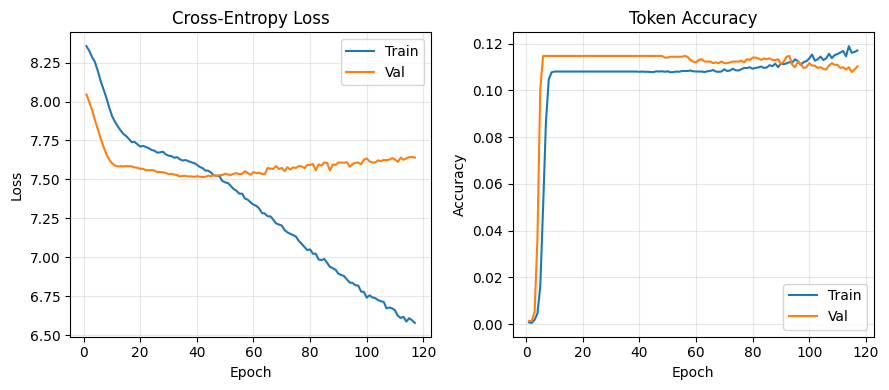

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
epochs_range = range(1, len(history["train_loss"]) + 1)

axes[0].plot(epochs_range, history["train_loss"], label="Train")
axes[0].plot(epochs_range, history["val_loss"],   label="Val")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Cross-Entropy Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, history["train_acc"], label="Train")
axes[1].plot(epochs_range, history["val_acc"],   label="Val")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Token Accuracy")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()

# Уникальное имя: параметры модели + временная метка
PLOTS_DIR = Path("training_plots")
PLOTS_DIR.mkdir(exist_ok=True)
_ts    = datetime.now().strftime("%Y%m%d_%H%M%S")
_fname = (
    f"bpe"
    f"_D{MODEL_CONFIG['d_model']}"
    f"_L{MODEL_CONFIG['num_layers']}"
    f"_H{MODEL_CONFIG['nhead']}"
    f"_drop{MODEL_CONFIG['dropout']}"
    f"_lr{LEARNING_RATE}"
    f"_{_ts}.png"
)
plt.savefig(PLOTS_DIR / _fname, dpi=150)
print(f"График сохранён: {PLOTS_DIR / _fname}")
plt.show()

## Оценка на тестовом наборе

In [20]:
model.load_state_dict(torch.load("best_model_bpe.pt", map_location=DEVICE))

test_loss, test_acc = evaluate(model, test_loader, criterion, DEVICE)
print(f"Test loss: {test_loss:.4f}")
print(f"Test token accuracy: {test_acc:.3f}")

Test loss: 7.5455
Test token accuracy: 0.118


## Пример инференса (greedy decode)

In [21]:
@torch.no_grad()
def greedy_decode(model, video_frames, max_len=MAX_TOKENS, device=DEVICE):
    """Авторегрессионная генерация токенов по видео."""
    model.eval()
    video = video_frames.unsqueeze(0).to(device)

    memory = model.encoder(video)
    if isinstance(memory, tuple):
        memory = memory[0]

    generated = [BOS_TOKEN_ID]

    for _ in range(max_len - 1):
        tgt = torch.tensor([generated], dtype=torch.long, device=device)
        logits = model.decoder(tgt, memory)
        next_token = logits[0, -1].argmax().item()
        generated.append(next_token)
        if next_token == EOS_TOKEN_ID:
            break

    tokens = [t for t in generated if t not in (BOS_TOKEN_ID, EOS_TOKEN_ID, PAD_TOKEN_ID)]
    return tokens


for i in range(min(5, len(test_dataset))):
    sample    = test_dataset[i]
    pred_ids  = greedy_decode(model, sample["frames"])
    pred_text = bpe_tokenizer.decode(pred_ids)

    gt_ids  = [t for t in sample["target"].tolist()
               if t not in (EOS_TOKEN_ID, PAD_TOKEN_ID)]
    gt_text = bpe_tokenizer.decode(gt_ids)

    print(f"[{i}] Predicted:    {pred_text}")
    print(f"[{i}] Ground truth: {gt_text}")
    print()

[0] Predicted:    
[0] Ground truth: London . O n tonight ' s program , undercover

[1] Predicted:    
[1] Ground truth: n tonight ' s program , undercover

[2] Predicted:    
[2] Ground truth: s program , undercover

[3] Predicted:    
[3] Ground truth: undercover

[4] Predicted:    
[4] Ground truth: of scandals at the Met are no thing new

